In [1]:
import pickle as pkl
import numpy as np
from pathlib import Path
import tarfile
import glob
import re
from collections import defaultdict, Counter
import itertools
import matplotlib.pyplot as plt
import pandas as pd
# import dionysus

# from helper_functions import *
# from KK_zz_apex_LS import *

from hierarchicalsoftmax import SoftmaxNode, HierarchicalSoftmaxLoss, HierarchicalSoftmaxLinear
from hierarchicalsoftmax.inference import (
    greedy_predictions,
    node_probabilities,
)

import numpy as np
from collections import defaultdict, Counter
import itertools
import pandas as pd
from sklearn.model_selection import StratifiedKFold, KFold

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim


/Users/levisvaren/anaconda3/envs/transformers/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# DeepTE

### Repbase

In [ ]:
df = pd.read_csv('../repbase_QC_051326.csv')

save_dir = '../DeepTE/Repbase'

for i in range(5):
    train = df[df[f"fold_{i}"] == 'train']
    test = df[df[f"fold_{i}"] == 'test']

    train_fa = f'{save_dir}/train_{i}.fasta'
    test_fa = f'{save_dir}/test_{i}.fasta'
     
    # Train
    seq = list(train['sequence'])
    order = list(train['order'])
    superfam = list(train['superfamily'])

    with open(train_fa, "w") as ff:
        for i, (s, o, sf) in enumerate(zip(seq, order, superfam)):
            ff.write(f">{o}_{sf}_{i}\n")
            ff.write(f"{s}\n")


    # Test
    seq = list(test['sequence'])
    order = list(test['order'])
    superfam = list(test['superfamily'])

    with open(test_fa, "w") as ff:
        for i, (s, o, sf) in enumerate(zip(seq, order, superfam)):
            ff.write(f">{o}_{sf}_{i}\n")
            ff.write(f"{s}\n")


### RepetDB

In [ ]:
df = pd.read_csv('../repetdb_QC_051326.csv')

save_dir = '../DeepTE/RepetDB'

for i in range(5):
    train = df[df[f"fold_{i}"] == 'train']
    test = df[df[f"fold_{i}"] == 'test']

    train_fa = f'{save_dir}/train_{i}.fasta'
    test_fa = f'{save_dir}/test_{i}.fasta'
     
    # Train
    seq = list(train['sequence'])
    order = list(train['order'])
    superfam = list(train['superfamily'])

    with open(train_fa, "w") as ff:
        for i, (s, o, sf) in enumerate(zip(seq, order, superfam)):
            ff.write(f">{o}_{sf}_{i}\n")
            ff.write(f"{s}\n")


    # Test
    seq = list(test['sequence'])
    order = list(test['order'])
    superfam = list(test['superfamily'])

    with open(test_fa, "w") as ff:
        for i, (s, o, sf) in enumerate(zip(seq, order, superfam)):
            ff.write(f">{o}_{sf}_{i}\n")
            ff.write(f"{s}\n")


### MnTEdb

In [ ]:
df = pd.read_csv('../mntedb_QC_051326.csv')

save_dir = '../DeepTE/MnTEdb'

for i in range(5):
    train = df[df[f"fold_{i}"] == 'train']
    test = df[df[f"fold_{i}"] == 'test']

    train_fa = f'{save_dir}/train_{i}.fasta'
    test_fa = f'{save_dir}/test_{i}.fasta'
     
    # Train
    seq = list(train['sequence'])
    order = list(train['order'])
    superfam = list(train['superfamily'])

    with open(train_fa, "w") as ff:
        for i, (s, o, sf) in enumerate(zip(seq, order, superfam)):
            ff.write(f">{o}_{sf}_{i}\n")
            ff.write(f"{s}\n")


    # Test
    seq = list(test['sequence'])
    order = list(test['order'])
    superfam = list(test['superfamily'])

    with open(test_fa, "w") as ff:
        for i, (s, o, sf) in enumerate(zip(seq, order, superfam)):
            ff.write(f">{o}_{sf}_{i}\n")
            ff.write(f"{s}\n")


# TERL

Dataset

    Train
        
        class1.fa

        class2.fa

    Test 

        class1.fa

        class2.fa

### Repbase

In [341]:
df = pd.read_csv('../repbase_QC_051326.csv')
dataset_dir = '../TERL/Repbase/'

for i in range(5):
    fold_dir = f"{dataset_dir}/fold_{i}/"
    order_dir = f"{fold_dir}/Order/"
    superfam_dir = f"{fold_dir}/Superfamily/"

    train = df[df[f"fold_{i}"] == 'train']
    test = df[df[f"fold_{i}"] == 'test']


    seq = list(train['sequence'])
    order = list(train['order'])
    superfam = list(train['superfamily'])

    # Order
    for l in list(set(order)):
        # Train
        save = f"{order_dir}/Train/{l}.fa"
        Path(f"{order_dir}/Train/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(train[train['order'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")
        # Test
        save = f"{order_dir}/Test/{l}.fa"
        Path(f"{order_dir}/Test/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(test[test['order'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")

    # Order
    for l in list(set(superfam)):
        # Train
        save = f"{superfam_dir}/Train/{l}.fa"
        Path(f"{superfam_dir}/Train/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(train[train['superfamily'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")
        # Test
        save = f"{superfam_dir}/Test/{l}.fa"
        Path(f"{superfam_dir}/Test/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(test[test['superfamily'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")


### RepetDB

In [340]:
df = pd.read_csv('../repetdb_QC_051326.csv')
dataset_dir = '../TERL/RepetDB/'

for i in range(5):
    fold_dir = f"{dataset_dir}/fold_{i}/"
    order_dir = f"{fold_dir}/Order/"
    superfam_dir = f"{fold_dir}/Superfamily/"

    train = df[df[f"fold_{i}"] == 'train']
    test = df[df[f"fold_{i}"] == 'test']


    seq = list(train['sequence'])
    order = list(train['order'])
    superfam = list(train['superfamily'])

    # Order
    for l in list(set(order)):
        # Train
        save = f"{order_dir}/Train/{l}.fa"
        Path(f"{order_dir}/Train/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(train[train['order'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")
        # Test
        save = f"{order_dir}/Test/{l}.fa"
        Path(f"{order_dir}/Test/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(test[test['order'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")

    # Order
    for l in list(set(superfam)):
        # Train
        save = f"{superfam_dir}/Train/{l}.fa"
        Path(f"{superfam_dir}/Train/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(train[train['superfamily'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")
        # Test
        save = f"{superfam_dir}/Test/{l}.fa"
        Path(f"{superfam_dir}/Test/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(test[test['superfamily'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")


### MnTEdb

In [339]:
df = pd.read_csv('../mntedb_QC_051326.csv')
dataset_dir = '../TERL/MnTEdb/'

for i in range(5):
    fold_dir = f"{dataset_dir}/fold_{i}/"
    order_dir = f"{fold_dir}/Order/"
    superfam_dir = f"{fold_dir}/Superfamily/"

    train = df[df[f"fold_{i}"] == 'train']
    test = df[df[f"fold_{i}"] == 'test']


    seq = list(train['sequence'])
    order = list(train['order'])
    superfam = list(train['superfamily'])

    # Order
    for l in list(set(order)):
        # Train
        save = f"{order_dir}/Train/{l}.fa"
        Path(f"{order_dir}/Train/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(train[train['order'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")
        # Test
        save = f"{order_dir}/Test/{l}.fa"
        Path(f"{order_dir}/Test/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(test[test['order'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")

    # Order
    for l in list(set(superfam)):
        # Train
        save = f"{superfam_dir}/Train/{l}.fa"
        Path(f"{superfam_dir}/Train/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(train[train['superfamily'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")
        # Test
        save = f"{superfam_dir}/Test/{l}.fa"
        Path(f"{superfam_dir}/Test/").mkdir(parents=True, exist_ok=True)
        seq_lst = list(test[test['superfamily'] == l]['sequence'])
        with open(save, "w") as ff:
            for i, s in enumerate(seq_lst):
                ff.write(f">sequence_{i}\n")
                ff.write(f"{s}\n")


In [337]:
train.shape

(93413, 15)

In [338]:
test.shape

(23353, 15)

# Persistence images

In [ ]:
import pandas as pd
import tarfile
import numpy as np
import pickle
import io
import itertools
from collections import Counter, defaultdict
import sys
import glob
# from gtda.diagrams import PersistenceImage
# from gtda.plotting import plot_heatmap
import dionysus
import numpy as np
from scipy.stats import multivariate_normal

In [140]:
def get_nuc_counts(nodes):
    results = []
    for t in nodes:
        combined_string = "".join(t)
        counts = dict(Counter(combined_string))
        results.append(counts)
    return results

def set_atgcx_5(data):
    rgb_atgcx = []
    # for data in all_node_counts_list:
    if len(data) > 0:
        a_val = data.get('a', 0)
        t_val = data.get('t', 0)
        g_val = data.get('g', 0)
        c_val = data.get('c', 0)
        x_val = data.get('x', 0)

        total = sum(data.values())
        a = (a_val / total) #* 255
        t = (t_val / total) #* 255
        g = (g_val / total) #* 255
        c = (c_val / total) #* 255
        x = (x_val / total) #* 255

        rgb_atgcx.append([a,t,g,c,x])
    else:
        rgb_atgcx.append([0,0,0,0,0])
    return rgb_atgcx


# def set_counts(all_node_counts_list):
#     rgb_atgcx = []
#     for data in all_node_counts_list:
        
#         a_val = data.get('a', 0)
#         t_val = data.get('t', 0)
#         g_val = data.get('g', 0)
#         c_val = data.get('c', 0)
#         x_val = data.get('x', 0)

#         total = sum(data.values())
#         a = (a_val) # / total) #* 255
#         t = (t_val) # / total) #* 255
#         g = (g_val) # / total) #* 255
#         c = (c_val) # / total) #* 255
#         x = (x_val)
#         rgb_atgcx.append((a,t,g,c,x))
#     return rgb_atgcx


def get_alphabet(a:list, k:int):
    alphabet = a * k
    combos = [''.join(c) for c in itertools.combinations(alphabet, k)]
    sorted_combos = sorted(set(combos)) 
    node_id = {node: i for i, node in enumerate(sorted_combos)} 

    return sorted_combos, node_id


def process_barcodes(obj):
    all_barcodes = []
    labels = []
    all_nodes = []
    all_node_counts = []
    for seq, value in obj.items():
        l = len(seq)
        for k, bd in value[0].items():

            if len(bd[-1]) == 0:
                b_d_times = []
                continue
            else:
                b_d_times = []
                for birth, death in bd[-1]:
                    if death == np.inf:
                        death = l
                    b_d_times.append([int(birth), int(death)-int(birth)]) # Calculate persistence
                labels.append(seq)
                all_barcodes.append(np.array(b_d_times))
            nodes = [tuple(id_to_node[num] for num in t) for t in bd[0]]
            all_nodes.append(nodes)

            node_counts = get_nuc_counts(nodes)
            all_node_counts.append(node_counts)

    return all_nodes, all_node_counts, all_barcodes, labels

def process_tarball(path, filename, target_dict_name):
    all_data = []
    labels = []
    # Open the tar.gz
    with tarfile.open(f"{path}/{filename}", "r:gz") as tar:
        for member in tar:

            if target_dict_name in member.name and member.isfile():
                pkl_file = tar.extractfile(member)

                if pkl_file:
                    obj = pickle.load(pkl_file)

                    # Get barcode and sequence
                    all_nodes, all_node_counts, all_barcodes, l = process_barcodes(obj)
                    all_data.append(all_barcodes)
                    labels.append(l)
    return all_data, labels, all_nodes, all_node_counts

def get_grid_and_weights(diagrams, n_bins=128, weight_func=None):

    all_births = np.concatenate([d[:, 0] for d in diagrams])
    all_pers = np.concatenate([d[:, 1] for d in diagrams])
    
    b_min, b_max = all_births.min(), all_births.max()
    p_min, p_max = all_pers.min(), all_pers.max()
    
    b_sampling = np.linspace(b_min, b_max, n_bins)
    p_sampling = np.linspace(p_min, p_max, n_bins)
    
    if weight_func is None:
        weights = np.ones(n_bins)
    else:
        weights = weight_func(p_sampling)
        
    return (b_sampling, p_sampling), weights

def generate_images_global_intensity(diagrams, sampling, weights, arr, sigma=0.5):
    b_samples, p_samples = sampling
    n_bins = len(b_samples)
    X, Y = np.meshgrid(b_samples, p_samples)
    grid_coords = np.dstack([X, Y])
    
    images = []
    
    for dgm in diagrams:

        # global_intensities = np.sum(dgm_channels, axis=0) / 255.0
        
        density_map = np.zeros((n_bins, n_bins))
        
        coords = np.vstack([dgm[:, 0], dgm[:, 1]]).T
        
        for i, point in enumerate(coords):
            rv = multivariate_normal(point, [[sigma, 0], [0, sigma]])
            pdf_slice = rv.pdf(grid_coords)
            
            p_idx = np.abs(p_samples - point[1]).argmin()
            w = weights[p_idx]
        
            density_map += (w * pdf_slice)
            
    img_5ch = density_map[:, :, np.newaxis] * arr
        
    images.append(img_5ch)
        
    return np.array(images)

In [42]:
path = '/Users/levisvaren/Downloads/040326/051926/'
filename = 'chunk_1.tar.gz'

target_dict_name = 'results'

all_data = []
labels = []
# Open the tar.gz
with tarfile.open(f"{path}/{filename}", "r:gz") as tar:
    for member in tar:

        if target_dict_name in member.name and member.isfile():
            pkl_file = tar.extractfile(member)

            if pkl_file:
                obj = pickle.load(pkl_file)
                
                # Get barcode and sequence
                # all_nodes, all_node_counts, all_barcodes, l = process_barcodes(obj)
                all_barcodes = []
                labels = []
                # all_nodes = [] # equivalent of cc
                all_node_counts = []
                for seq, value in obj.items():
                    l = len(seq)

                    barcodes = list(value[0]['barcode_H1'])
                    elements = list(value[0]['barcode_elements_H1'])
                    node_id = value[0]['node_id']
                    id_to_node = {v:k for k,v in node_id.items()}

                    ccs = [tuple(id_to_node[num] for num in t) for t in elements] # list of connected components
                    nodes = [node for edge in ccs for node in edge]
                    combined_string = "".join(nodes)
                    node_counts = dict(Counter(combined_string)) # counts of atgcx for given sequence
                    
                    b_d_times = []

                    # Iterate through each CC and its birth/death times
                    for bd, cc in zip(barcodes, ccs):
                        
                        if len(bd) == 0:
                            continue
                        else:
                            birth, death = bd
                            if death == np.inf:
                                death = l
                            b_d_times.append([int(birth), int(death)-int(birth)]) # Calculate persistence
                            
                    if len(b_d_times) > 0:
                        labels.append(seq)
                        all_barcodes.append(np.array(b_d_times))
                        all_data.append(node_counts)


In [ ]:

rgb_atgcx = set_atgcx_5(all_data)
atgcx = set_counts(all_data)

persistence_images = {}

for b,s,arr,c in zip(all_barcodes, labels, rgb_atgcx, atgcx):
    diagrams = [b]

    sampling, weights = get_grid_and_weights(diagrams, n_bins=128, weight_func=None)
    image = generate_images_global_intensity(diagrams, sampling, weights, [arr], sigma=0.5)
    if image.max() > 0:
        image = image / image.max()
    
    persistence_images[s] = {'persistence_image': image.squeeze(), 'intensities': [arr], 'inten_counts':[c]}

# save_name = filename.replace('.tar.gz', '')
# with open(f"./{save_name}.pkl", "wb") as f:
#     pickle.dump(persistence_images, f)

In [108]:
from scipy.stats import multivariate_normal

In [ ]:
import pickle

path = '/Users/levisvaren/Downloads/040326/051926/chunk_1'
filename = 'results_chunk_1_4mer.pkl'


with open(f"{path}/{filename}", "rb") as file:
    data = pickle.load(file)


In [204]:
seq

'tgctagatttaaaatgatctcaacacaatctaaacaagataaaaaacaataatctagcaatacatatgaaaataccataaaacttatttaagatttaggcatacattgaagtggacaaaggaagattacctcttccggtaggcagtgaaaaagcgtaccccacgattgcggaatccaccaatagccggccggaatcaatggaggacctgcaaataagaagaaaagttgtaggaagtgctcttgagctcctcctatctctccctctctgcccctttcacatttgtagcacacacacacaagcacaagcccacctcttctaaagaatgggtgctactaataaaaaccaaataggcctaagggcttttaatcaatattcaatggagagggtatttagtccaataggctgacaaaatattatgagatagaaagagttcatatgcctcaagcgagttaataaaataagtgtccatcccattatggattgatatttaacatacatgcatgtgttaattcacattaacatagttgtctataaaatgccttattaattaaagagtgaattattatgattatagaaatccacataaaaatattctaacagtctcccacttagacgacataatcaaacaacaaacatttactcatcacaacataagcatcaactaagaatctcacataataaacacaagcccaaaacaatcatgcataataacatatcgacaagatataatcattatacataatcaggcgttagagattcatcaaagcatgatgacaaattaatatatggatcaagagctaccaaatgtctcattttttcatgtcacttatcaaccaaaaagtgtgtcaacacaatatcacatacaaagtgacaagatccataaatacgcatgtattatttgaggcataagcaatccttaacaataacaacatgtcacacacaaatgacaataaactcccactaactcaatacaactacaggctctttacagtcctcga

In [207]:
persistence_images = {}

for seq, value in data.items():
    l = len(seq)
    barcodes = list(value[0]['barcode_H1'])
    elements = list(value[0]['barcode_elements_H1'])
    node_id = value[0]['node_id']
    id_to_node = {v:k for k,v in node_id.items()}

    ccs = [tuple(id_to_node[num] for num in t) for t in elements] # list of connected components
    nodes = [node for edge in ccs for node in edge]

    b_d_times = []
    
    current_compositions = []
    current_b_d_points = []

    for bd, cc in zip(barcodes, ccs):
        if len(bd) == 0:
            continue
        else:
            birth, death = bd
            if death == np.inf:
                death = l

        current_b_d_points.append([birth, death])
        
        # Get composition of cc
        combined_string = "".join(list(cc))
        node_counts = dict(Counter(combined_string))
        
        feature_composition = set_atgcx_5(node_counts) #get fractions
        current_compositions.append(feature_composition[0])
        
    sequence_diagram = np.array(current_b_d_points) #(N,2)
    sequence_compositions = np.array(current_compositions) #(N,5)

    N = sequence_diagram.shape[0]
    resolution = 128
    sigma = 1

    # Calculate persistences
    births = sequence_diagram[:, 0]
    persistences = sequence_diagram[:, 1] - sequence_diagram[:, 0]

    # Max persistence and birth values
    max_p = persistences.max()
    range_birth = (0, births.max())
    range_persistence = (0, max_p)

    # Grids
    b_grid = np.linspace(range_birth[0], range_birth[1], resolution)
    p_grid = np.linspace(range_persistence[0], range_persistence[1], resolution)
    B_mesh, P_mesh = np.meshgrid(b_grid, p_grid)
    grid_coords = np.dstack((B_mesh, P_mesh))

    # Empty 5 channel PI
    five_channel_pi = np.zeros((resolution, resolution, 5))

    # Gaussian distribution kernel
    for i in range(N):
        b_pt = births[i] #0
        p_pt = persistences[i] #1
        mean = [b_pt, p_pt]
        w_pt = 1 #no weights
        
        if p_pt <= 0:  # Skip negative
            continue
            
        # CC fractions
        comp_vector = sequence_compositions[i] 
        
        # Gaussian
        rv = multivariate_normal([b_pt,p_pt], [[sigma, 0], [0, sigma]])
        pdf_slice = rv.pdf(grid_coords)
        gaussian_kernel = pdf_slice.reshape(resolution, resolution)
        # gaussian_kernel = gaussian_kernel * (2 * np.pi * sigma**2)

        # Base localized persistence intensity
        base_intensity = w_pt * gaussian_kernel
        
        # Distribute base intensity across channels scaled by nucleotide composition
        for channel_idx in range(5):
            five_channel_pi[:, :, channel_idx] += base_intensity * comp_vector[channel_idx]
        
        if five_channel_pi.max() > 0:
            five_channel_pi = five_channel_pi / five_channel_pi.max() #scale [0-1]
    

    # Add to PI dict
    persistence_images[seq] = {'persistence_image': five_channel_pi}

KeyboardInterrupt: 

In [202]:
current_compositions = []
current_b_d_points = []

for bd, cc in zip(barcodes, ccs):
    if len(bd) == 0:
        continue
    else:
        birth, death = bd
        if death == np.inf:
            death = l

    current_b_d_points.append([birth, death])
    
    # Get composition of cc
    combined_string = "".join(list(cc))
    node_counts = dict(Counter(combined_string))
    
    feature_composition = set_atgcx_5(node_counts) #get fractions
    current_compositions.append(feature_composition[0])
    
sequence_diagram = np.array(current_b_d_points) #(N,2)
sequence_compositions = np.array(current_compositions) #(N,5)

N = sequence_diagram.shape[0]
resolution = 128
sigma = 1

# Calculate persistences
births = sequence_diagram[:, 0]
persistences = sequence_diagram[:, 1] - sequence_diagram[:, 0]

# Max persistence and birth values
max_p = persistences.max()
range_birth = (0, births.max())
range_persistence = (0, max_p)

# Grids
b_grid = np.linspace(range_birth[0], range_birth[1], resolution)
p_grid = np.linspace(range_persistence[0], range_persistence[1], resolution)
B_mesh, P_mesh = np.meshgrid(b_grid, p_grid)
grid_coords = np.dstack((B_mesh, P_mesh))

# Empty 5 channel PI
five_channel_pi = np.zeros((resolution, resolution, 5))

# Gaussian distribution kernel
for i in range(N):
    b_pt = births[i] #0
    p_pt = persistences[i] #1
    mean = [b_pt, p_pt]
    w_pt = 1 #no weights
    
    if p_pt <= 0:  # Skip negative
        continue
        
    # CC fractions
    comp_vector = sequence_compositions[i] 
    
    # Gaussian
    rv = multivariate_normal([b_pt,p_pt], [[sigma, 0], [0, sigma]])
    pdf_slice = rv.pdf(grid_coords)
    gaussian_kernel = pdf_slice.reshape(resolution, resolution)
    # gaussian_kernel = gaussian_kernel * (2 * np.pi * sigma**2) #Scale??

    # Base localized persistence intensity
    base_intensity = w_pt * gaussian_kernel
    
    # Distribute base intensity across channels scaled by nucleotide composition
    for channel_idx in range(5):
        five_channel_pi[:, :, channel_idx] += base_intensity * comp_vector[channel_idx]
    five_channel_pi = five_channel_pi / five_channel_pi.max() #scale [0-1]
    


In [ ]:
for seq, value, in persistence_images.items():
    pi = value['persistence_image']
    vmin, vmax = pi.min(), pi.max()

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    for i in range(5):
        # Index the last dimension: image_np[:, :, i]
        im = axes[i].imshow(pi[:, :, i], cmap='magma', vmin=vmin, vmax=vmax)
        
        axes[i].axis('off')

# PI example with new code

In [ ]:
def set_atgcx_5(data):
    rgb_atgcx = []
    # for data in all_node_counts_list:
    if len(data) > 0:
        a_val = data.get('A', 0)
        t_val = data.get('T', 0)
        g_val = data.get('G', 0)
        c_val = data.get('C', 0)
        x_val = data.get('X', 0)

        total = sum(data.values())
        a = (a_val / total) #* 255
        t = (t_val / total) #* 255
        g = (g_val / total) #* 255
        c = (c_val / total) #* 255
        x = (x_val / total) #* 255

        rgb_atgcx.append([a,t,g,c,x])
    else:
        rgb_atgcx.append([0,0,0,0,0])
    return rgb_atgcx

ccs = [
    ('AT', 'TA', 'AC', 'CA'),
    ('AT', 'TA', 'AC', 'CA'),
    ('AT', 'TA', 'AC', 'CA'),

    ('CA', 'AC', 'CC', 'AA'),
    ('CA', 'AC', 'CC', 'AA'),

    ('AG', 'GT', 'TG', 'GC', 'CA'),
    ('AG', 'GT', 'TG', 'GC', 'CA'),

    ('AA', 'AC', 'AG', 'GA'),
    ('AA', 'AC', 'AG', 'GA'),
    ('AA', 'AC', 'AG', 'GA'),
    ('AA', 'AC', 'AG', 'GA')
]

barcodes = [
    (0, 5), (9, 3), (15,2),
    (3, 5), (13,2),
    (5,4), (17,4),
    (10,2), (13,2), (16, 2), (19,2)
]


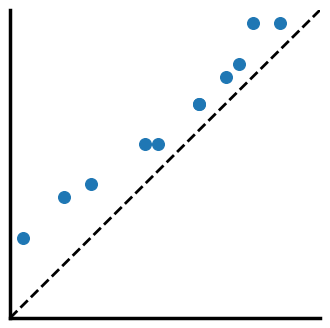

In [314]:
arr1 = np.array([[10,12], [13,15], [16,18], [19,21]])
arr2 = np.array([[5,9], [17,21]])
arr3 = np.array([[3,8], [13,15]])
arr4 = np.array([[0,5], [9,12], [15,17]])

arr = np.vstack([arr1, arr2, arr3, arr4])

plt.figure(figsize=(4,4))
plt.xlim(-1, 22)
plt.ylim(-1, 22)
plt.scatter(arr[:, 0], arr[:, 1], s=70)
plt.axline((0,0), slope=1, color='black', linestyle='--', linewidth=2)
plt.xlabel('')
plt.ylabel('')


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)

ax.spines['bottom'].set_linewidth(2.5)
ax.spines['left'].set_linewidth(2.5)

ax.set_xticks([])
ax.set_yticks([])
plt.show()

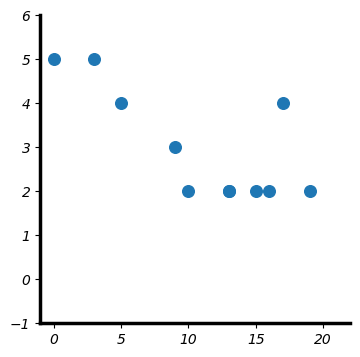

In [ ]:
barcodes = [
    (0, 5), (9, 3), (15,2),
    (3, 5), (13,2),
    (5,4), (17,4),
    (10,2), (13,2), (16, 2), (19,2)
]

arr_bar = np.array(barcodes)

plt.figure(figsize=(4,4))
plt.xlim(-1, 22)
plt.ylim(-1, 6)
plt.scatter(arr_bar[:, 0], arr_bar[:, 1], s=70)
# plt.axline((0,0), slope=1, color='black', linestyle='--', linewidth=2)
plt.xlabel('')
plt.ylabel('')


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True) 

ax.spines['bottom'].set_linewidth(2.5)
ax.spines['left'].set_linewidth(2.5)

# ax.set_xticks([])
# ax.set_yticks([])
plt.show()

In [262]:
arr1 = np.array([[10,12], [13,15], [16,18], [19,21]])
arr2 = np.array([[5,9], [17,21]])
arr3 = np.array([[3,8], [13,15]])
arr4 = np.array([[0,5], [9,12], [15,17]])

data = {
    ('AT', 'TA', 'AC', 'CA'): arr1,
    ('CA', 'AC', 'CC', 'AA'): arr2,
    ('AG', 'GT', 'TG', 'GC', 'CA'): arr3,
    ('AA', 'AC', 'AG', 'GA'): arr4
}

In [266]:
ccs = []
barcodes = []

for key, value in data.items():
    for v in value:
        ccs.append(key)
        barcodes.append(v)

In [327]:
current_compositions = []
current_b_d_points = []

for bd, cc in zip(barcodes, ccs):
    if len(bd) == 0:
        continue
    else:
        birth, death = bd
        if death == np.inf:
            death = l

    current_b_d_points.append([birth, death])
    
    # Get composition of cc
    combined_string = "".join(list(cc))
    node_counts = dict(Counter(combined_string))
    
    feature_composition = set_atgcx_5(node_counts) #get fractions
    current_compositions.append(feature_composition[0])
    
sequence_diagram = np.array(current_b_d_points) #(N,2)
sequence_compositions = np.array(current_compositions) #(N,5)

N = sequence_diagram.shape[0]
resolution = 128
sigma = 1

# Calculate persistences
births = sequence_diagram[:, 0]
persistences = sequence_diagram[:, 1] - sequence_diagram[:, 0]

# Max persistence and birth values
max_p = persistences.max()
range_birth = (0, births.max())
range_persistence = (0, max_p)

# Grids
# b_grid = np.linspace(range_birth[0], range_birth[1], resolution)
# p_grid = np.linspace(range_persistence[0], range_persistence[1], resolution)
b_grid = np.linspace(0, range_birth[1], resolution)
p_grid = np.linspace(0, range_persistence[1], resolution)
B_mesh, P_mesh = np.meshgrid(b_grid, p_grid)
grid_coords = np.dstack((B_mesh, P_mesh))

# Empty 5 channel PI
five_channel_pi = np.zeros((resolution, resolution, 5))

# Gaussian distribution kernel
for i in range(N):
    b_pt = births[i] #0
    p_pt = persistences[i] #1
    mean = [b_pt, p_pt]
    w_pt = 1 #no weights
    
    if p_pt <= 0:  # Skip negative
        continue
        
    # CC fractions
    comp_vector = sequence_compositions[i] 
    
    # Gaussian
    rv = multivariate_normal([b_pt,p_pt], [[sigma, 0], [0, sigma]])
    pdf_slice = rv.pdf(grid_coords)
    gaussian_kernel = pdf_slice.reshape(resolution, resolution)
    # gaussian_kernel = gaussian_kernel * (2 * np.pi * sigma**2) #Scale??

    # Base localized persistence intensity
    base_intensity = w_pt * gaussian_kernel
    
    # Distribute base intensity across channels scaled by nucleotide composition
    for channel_idx in range(5):
        five_channel_pi[:, :, channel_idx] += base_intensity * comp_vector[channel_idx]
        
if five_channel_pi.max() > 0:
    five_channel_pi = five_channel_pi / five_channel_pi.max() #scale [0-1]
    


A Channel Max: 1.0000
T Channel Max: 0.4004
G Channel Max: 0.4000
C Channel Max: 0.4004
X Channel Max: 0.0000


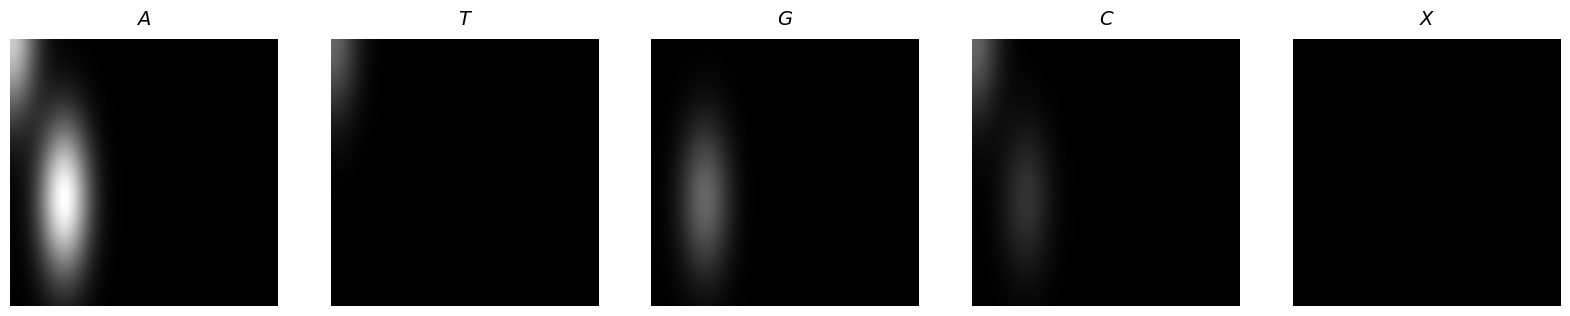

In [328]:
channel_names = ['A', 'T', 'G', 'C', 'X']
vmin, vmax = five_channel_pi.min(), five_channel_pi.max()
flipped = np.flipud(five_channel_pi)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i in range(5):
    # Index the last dimension: image_np[:, :, i]
    channel_max = flipped[:, :, i].max()
    print(f"{channel_names[i]} Channel Max: {channel_max:.4f}")

    im = axes[i].imshow(flipped[:, :, i], cmap='gray', vmin=vmin, vmax=vmax)
    
    axes[i].axis('off')
    axes[i].set_title(channel_names[i], fontsize=14, pad=10)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

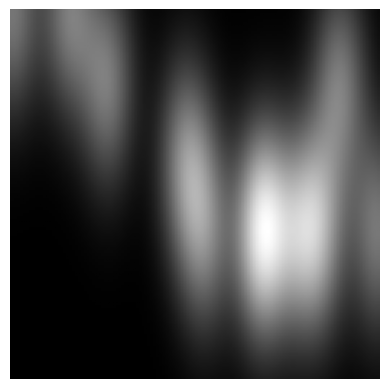

In [282]:
single_channel = np.sum(flipped, axis=2)

plt.imshow(single_channel, cmap='gray')
plt.axis('off')

In [ ]:
arr1 = np.array([[10,12], [13,15], [16,18], [19,21]])
arr2 = np.array([[5,9], [17,21]])
arr3 = np.array([[3,8], [13,15]])
arr4 = np.array([[0,5], [9,12], [15,17]])


data = {
    ('AT', 'TA', 'AC', 'CA'): arr1,
    ('CA', 'AC', 'CC', 'AA'): arr2,
    ('AG', 'GT', 'TG', 'GC', 'CA'): arr3,
    ('AA', 'AC', 'AG', 'GA'): arr4
}

In [322]:
ccs = [
    ('AT', 'TA', 'AC', 'CA'),
    ('CA', 'AC', 'CC', 'AA'),
    ('AG', 'GT', 'TG', 'GC', 'CA'),
    ('AA', 'AC', 'AG', 'GA')
]

for cc in ccs:
    combined_string = "".join(list(cc))
    node_counts = dict(Counter(combined_string))
    feature_composition = set_atgcx_5(node_counts)
    print(cc)
    print(feature_composition)

('AT', 'TA', 'AC', 'CA')
[[0.5, 0.25, 0.0, 0.25, 0.0]]
('CA', 'AC', 'CC', 'AA')
[[0.5, 0.0, 0.0, 0.5, 0.0]]
('AG', 'GT', 'TG', 'GC', 'CA')
[[0.2, 0.2, 0.4, 0.2, 0.0]]
('AA', 'AC', 'AG', 'GA')
[[0.625, 0.0, 0.25, 0.125, 0.0]]
